## 1. Setup and Imports

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"Pillow version: {Image.__version__}")

# Create output directories
os.makedirs('../results/pca', exist_ok=True)
os.makedirs('../results/pca/reconstructed', exist_ok=True)
os.makedirs('../results/pca/analysis', exist_ok=True)
print("\n✓ Output directories ready")

✓ All libraries imported successfully!
NumPy version: 2.3.4
OpenCV version: 4.12.0
Pillow version: 12.0.0

✓ Output directories ready


## 2. Load and Prepare Image

Load the image and convert it to grayscale for PCA analysis.

✓ Image loaded from: ../data/Sample_Image_for_Object_Detection.png

Image Information:
  RGB Shape: (966, 2560, 3)
  Grayscale Shape: (966, 2560)
  Width x Height: 2560 x 966 pixels
  Total pixels: 2,472,960
  Data type: uint8
  Value range: [0, 255]
  Mean: 161.34
  Std Dev: 74.21


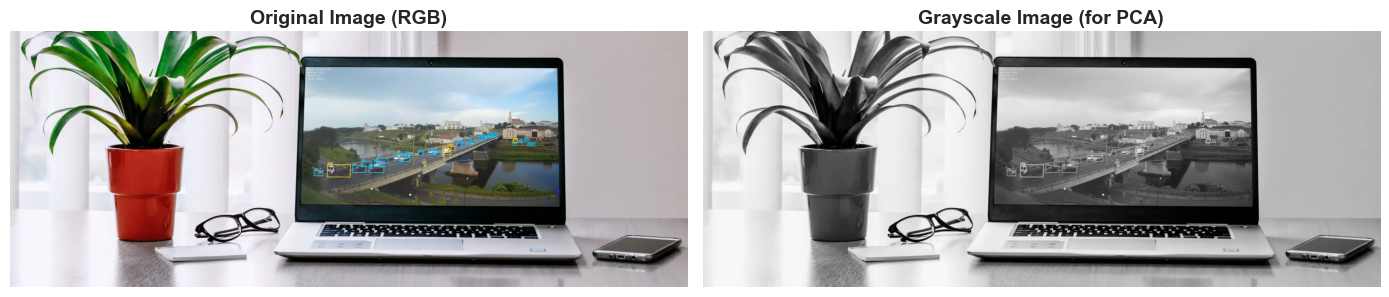

In [2]:
def load_image(image_path):
    """
    Load and prepare image for PCA analysis.
    """
    if not os.path.exists(image_path):
        print(f"⚠ Image not found at: {image_path}")
        print("Creating a sample image for demonstration...")
        
        # Create a sample grayscale image with patterns
        sample_img = np.ones((300, 400), dtype=np.uint8) * 200
        
        # Add patterns
        for i in range(0, 300, 20):
            cv2.line(sample_img, (0, i), (400, i), 50, 2)
        for j in range(0, 400, 20):
            cv2.line(sample_img, (j, 0), (j, 300), 100, 2)
        
        # Add some shapes
        cv2.circle(sample_img, (100, 150), 50, 255, -1)
        cv2.rectangle(sample_img, (250, 100), (350, 200), 0, -1)
        
        # Save sample image
        os.makedirs(os.path.dirname(image_path), exist_ok=True)
        cv2.imwrite(image_path, sample_img)
        print(f"✓ Sample image created at: {image_path}")
        
        return sample_img, sample_img
    
    # Load image
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    
    print(f"✓ Image loaded from: {image_path}")
    return image_rgb, image_gray

# Load the image
image_path = '../data/Sample_Image_for_Object_Detection.png'
original_image_rgb, original_image_gray = load_image(image_path)

# Display image information
print(f"\nImage Information:")
print("="*50)
print(f"  RGB Shape: {original_image_rgb.shape}")
print(f"  Grayscale Shape: {original_image_gray.shape}")
print(f"  Width x Height: {original_image_gray.shape[1]} x {original_image_gray.shape[0]} pixels")
print(f"  Total pixels: {original_image_gray.size:,}")
print(f"  Data type: {original_image_gray.dtype}")
print(f"  Value range: [{original_image_gray.min()}, {original_image_gray.max()}]")
print(f"  Mean: {original_image_gray.mean():.2f}")
print(f"  Std Dev: {original_image_gray.std():.2f}")

# Display the original images
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(original_image_rgb)
axes[0].set_title('Original Image (RGB)', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(original_image_gray, cmap='gray')
axes[1].set_title('Grayscale Image (for PCA)', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../results/pca/analysis/original_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Prepare Data for PCA

Reshape the image matrix and normalize the data.

In [3]:
# Store original shape for reconstruction
original_shape = original_image_gray.shape
height, width = original_shape

# Convert image to float for better precision
image_float = original_image_gray.astype(np.float64)

# Normalize to [0, 1] range
image_normalized = image_float / 255.0

print("Data Preparation:")
print("="*50)
print(f"  Original shape: {original_shape}")
print(f"  Original dimensions: {width} x {height}")
print(f"  Total features (columns): {width}")
print(f"  Total samples (rows): {height}")
print(f"  Normalized range: [{image_normalized.min():.3f}, {image_normalized.max():.3f}]")

# PCA will be applied on rows (treating each row as a sample)
# Each row represents one horizontal line of the image
print(f"\n📊 PCA Configuration:")
print(f"  Input matrix: {height} rows × {width} columns")
print(f"  Each row: One horizontal line of pixels")
print(f"  Maximum components: {min(height, width)}")

Data Preparation:
  Original shape: (966, 2560)
  Original dimensions: 2560 x 966
  Total features (columns): 2560
  Total samples (rows): 966
  Normalized range: [0.000, 1.000]

📊 PCA Configuration:
  Input matrix: 966 rows × 2560 columns
  Each row: One horizontal line of pixels
  Maximum components: 966


## 4. Apply PCA and Analyze Components

Perform PCA to find principal components and analyze variance explained.

In [4]:
# Apply PCA with all components first to analyze
print("Performing PCA analysis...")
print("-" * 50)

pca_full = PCA()
pca_full.fit(image_normalized)

# Get explained variance
explained_variance = pca_full.explained_variance_
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("\n✓ PCA analysis complete!")
print(f"  Total components: {len(explained_variance_ratio)}")
print(f"  First component explains: {explained_variance_ratio[0]:.2%} of variance")
print(f"  Top 10 components explain: {cumulative_variance[9]:.2%} of variance")
print(f"  Top 50 components explain: {cumulative_variance[49]:.2%} of variance" if len(cumulative_variance) > 49 else "")

# Find number of components for different variance thresholds
thresholds = [0.80, 0.90, 0.95, 0.99]
print(f"\n📊 Components needed for variance thresholds:")
for threshold in thresholds:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    compression_ratio = (original_shape[0] * original_shape[1]) / (n_components * (original_shape[0] + original_shape[1]))
    print(f"  {threshold:.0%} variance: {n_components} components (compression: {compression_ratio:.2f}x)")

Performing PCA analysis...
--------------------------------------------------

✓ PCA analysis complete!
  Total components: 966
  First component explains: 50.22% of variance
  Top 10 components explain: 84.42% of variance
  Top 50 components explain: 96.69% of variance

📊 Components needed for variance thresholds:
  80% variance: 7 components (compression: 100.19x)
  90% variance: 19 components (compression: 36.91x)
  95% variance: 36 components (compression: 19.48x)
  99% variance: 111 components (compression: 6.32x)

✓ PCA analysis complete!
  Total components: 966
  First component explains: 50.22% of variance
  Top 10 components explain: 84.42% of variance
  Top 50 components explain: 96.69% of variance

📊 Components needed for variance thresholds:
  80% variance: 7 components (compression: 100.19x)
  90% variance: 19 components (compression: 36.91x)
  95% variance: 36 components (compression: 19.48x)
  99% variance: 111 components (compression: 6.32x)


## 5. Visualize Explained Variance

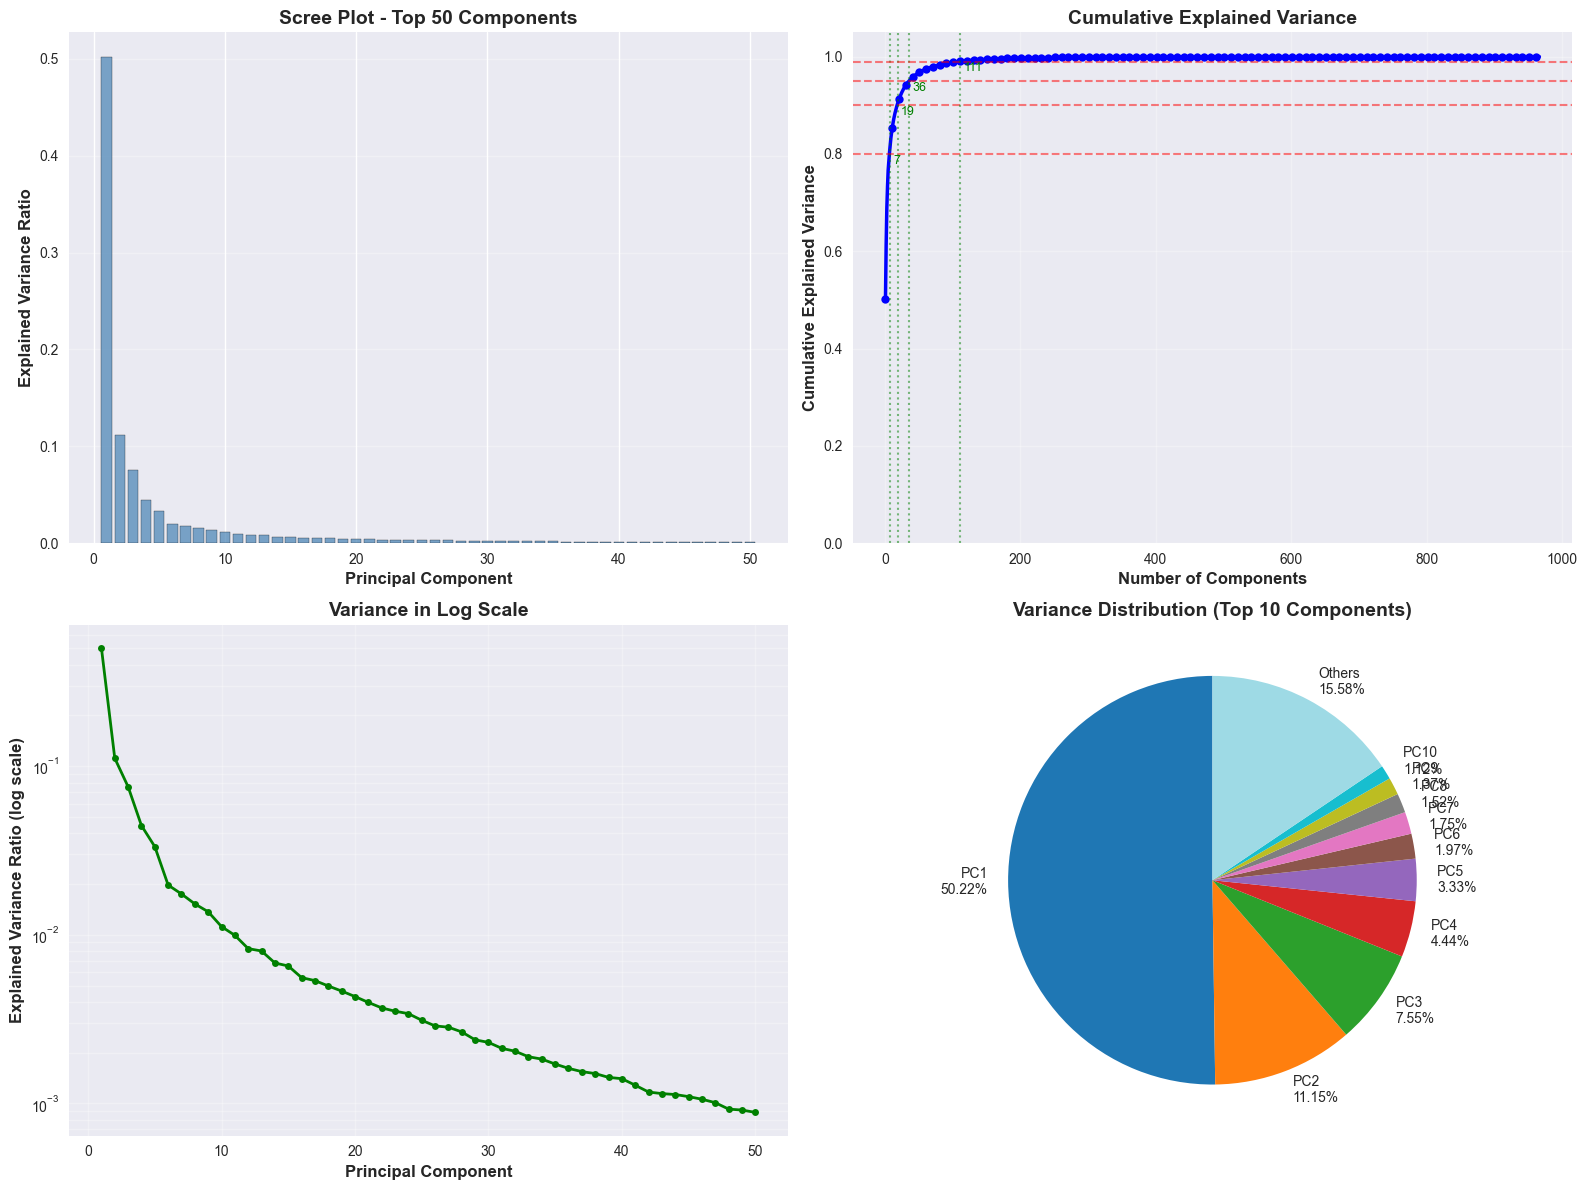

✓ Variance analysis visualized


In [5]:
# Create comprehensive variance visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scree plot - Individual variance
ax1 = axes[0, 0]
n_show = min(50, len(explained_variance_ratio))
ax1.bar(range(1, n_show + 1), explained_variance_ratio[:n_show], 
        color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Principal Component', fontsize=12, fontweight='bold')
ax1.set_ylabel('Explained Variance Ratio', fontsize=12, fontweight='bold')
ax1.set_title(f'Scree Plot - Top {n_show} Components', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 2. Cumulative variance
ax2 = axes[0, 1]
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
         'b-', linewidth=2.5, marker='o', markevery=10, markersize=6)
for threshold in thresholds:
    n_comp = np.argmax(cumulative_variance >= threshold) + 1
    ax2.axhline(y=threshold, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
    ax2.axvline(x=n_comp, color='green', linestyle=':', alpha=0.5, linewidth=1.5)
    ax2.text(n_comp + 5, threshold - 0.02, f'{n_comp}', fontsize=9, color='green')
ax2.set_xlabel('Number of Components', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Explained Variance', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.05])

# 3. Log scale variance
ax3 = axes[1, 0]
ax3.semilogy(range(1, n_show + 1), explained_variance_ratio[:n_show], 
             'go-', linewidth=2, markersize=5)
ax3.set_xlabel('Principal Component', fontsize=12, fontweight='bold')
ax3.set_ylabel('Explained Variance Ratio (log scale)', fontsize=12, fontweight='bold')
ax3.set_title('Variance in Log Scale', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, which='both')

# 4. Variance contribution pie chart (top 10)
ax4 = axes[1, 1]
n_pie = min(10, len(explained_variance_ratio))
top_variance = explained_variance_ratio[:n_pie]
other_variance = 1 - sum(top_variance)
pie_data = list(top_variance) + [other_variance]
labels = [f'PC{i+1}\n{v:.2%}' for i, v in enumerate(top_variance)] + [f'Others\n{other_variance:.2%}']
colors = plt.cm.tab20(np.linspace(0, 1, len(pie_data)))
wedges, texts = ax4.pie(pie_data, labels=labels, colors=colors, startangle=90)
ax4.set_title(f'Variance Distribution (Top {n_pie} Components)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/pca/analysis/variance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Variance analysis visualized")

## 6. Image Reconstruction with Different Numbers of Components

Reconstruct the image using different numbers of principal components.

In [6]:
def reconstruct_image(pca_model, data, n_components, original_shape):
    """
    Reconstruct image using specified number of components.
    """
    # Transform to PCA space
    data_transformed = pca_model.transform(data)[:, :n_components]
    
    # Reconstruct using only n_components
    data_reconstructed = np.dot(data_transformed, pca_model.components_[:n_components, :])
    data_reconstructed += pca_model.mean_
    
    # Clip values to valid range [0, 1]
    data_reconstructed = np.clip(data_reconstructed, 0, 1)
    
    return data_reconstructed

def calculate_metrics(original, reconstructed):
    """
    Calculate quality metrics for reconstruction.
    """
    # Mean Squared Error
    mse = np.mean((original - reconstructed) ** 2)
    
    # Peak Signal-to-Noise Ratio
    if mse == 0:
        psnr = float('inf')
    else:
        psnr = 20 * np.log10(1.0 / np.sqrt(mse))
    
    # Structural Similarity (simplified)
    mean_orig = np.mean(original)
    mean_recon = np.mean(reconstructed)
    var_orig = np.var(original)
    var_recon = np.var(reconstructed)
    cov = np.mean((original - mean_orig) * (reconstructed - mean_recon))
    
    c1 = 0.01 ** 2
    c2 = 0.03 ** 2
    ssim = ((2 * mean_orig * mean_recon + c1) * (2 * cov + c2)) / \
           ((mean_orig**2 + mean_recon**2 + c1) * (var_orig + var_recon + c2))
    
    return mse, psnr, ssim

# Test different numbers of components
component_counts = [5, 10, 25, 50, 100, 200]
# Filter to valid component counts
component_counts = [n for n in component_counts if n <= len(explained_variance_ratio)]

print("Reconstructing images with different numbers of components...")
print("="*70)

reconstructions = {}
metrics = {}

for n_comp in component_counts:
    # Reconstruct image
    reconstructed = reconstruct_image(pca_full, image_normalized, n_comp, original_shape)
    
    # Calculate metrics
    mse, psnr, ssim = calculate_metrics(image_normalized, reconstructed)
    
    # Calculate compression ratio
    original_size = height * width
    compressed_size = n_comp * (height + width)  # components + mean vector
    compression_ratio = original_size / compressed_size
    
    # Store results
    reconstructions[n_comp] = reconstructed
    metrics[n_comp] = {
        'mse': mse,
        'psnr': psnr,
        'ssim': ssim,
        'variance_explained': cumulative_variance[n_comp - 1],
        'compression_ratio': compression_ratio
    }
    
    print(f"\n{n_comp} components:")
    print(f"  Variance explained: {cumulative_variance[n_comp - 1]:.2%}")
    print(f"  MSE: {mse:.6f}")
    print(f"  PSNR: {psnr:.2f} dB")
    print(f"  SSIM: {ssim:.4f}")
    print(f"  Compression ratio: {compression_ratio:.2f}x")

print("\n✓ Image reconstruction complete!")

Reconstructing images with different numbers of components...

5 components:
  Variance explained: 76.69%
  MSE: 0.013294
  PSNR: 18.76 dB
  SSIM: 0.9148
  Compression ratio: 140.27x

10 components:
  Variance explained: 84.42%
  MSE: 0.008838
  PSNR: 20.54 dB
  SSIM: 0.9450
  Compression ratio: 70.13x

25 components:
  Variance explained: 92.62%
  MSE: 0.004154
  PSNR: 23.82 dB
  SSIM: 0.9749
  Compression ratio: 28.05x

50 components:
  Variance explained: 96.69%
  MSE: 0.001867
  PSNR: 27.29 dB
  SSIM: 0.9889
  Compression ratio: 14.03x

100 components:
  Variance explained: 98.82%
  MSE: 0.000672
  PSNR: 31.73 dB
  SSIM: 0.9960
  Compression ratio: 7.01x

200 components:
  Variance explained: 99.70%
  MSE: 0.000170
  PSNR: 37.71 dB
  SSIM: 0.9990
  Compression ratio: 3.51x

✓ Image reconstruction complete!

200 components:
  Variance explained: 99.70%
  MSE: 0.000170
  PSNR: 37.71 dB
  SSIM: 0.9990
  Compression ratio: 3.51x

✓ Image reconstruction complete!


## 7. Visualize Reconstructed Images

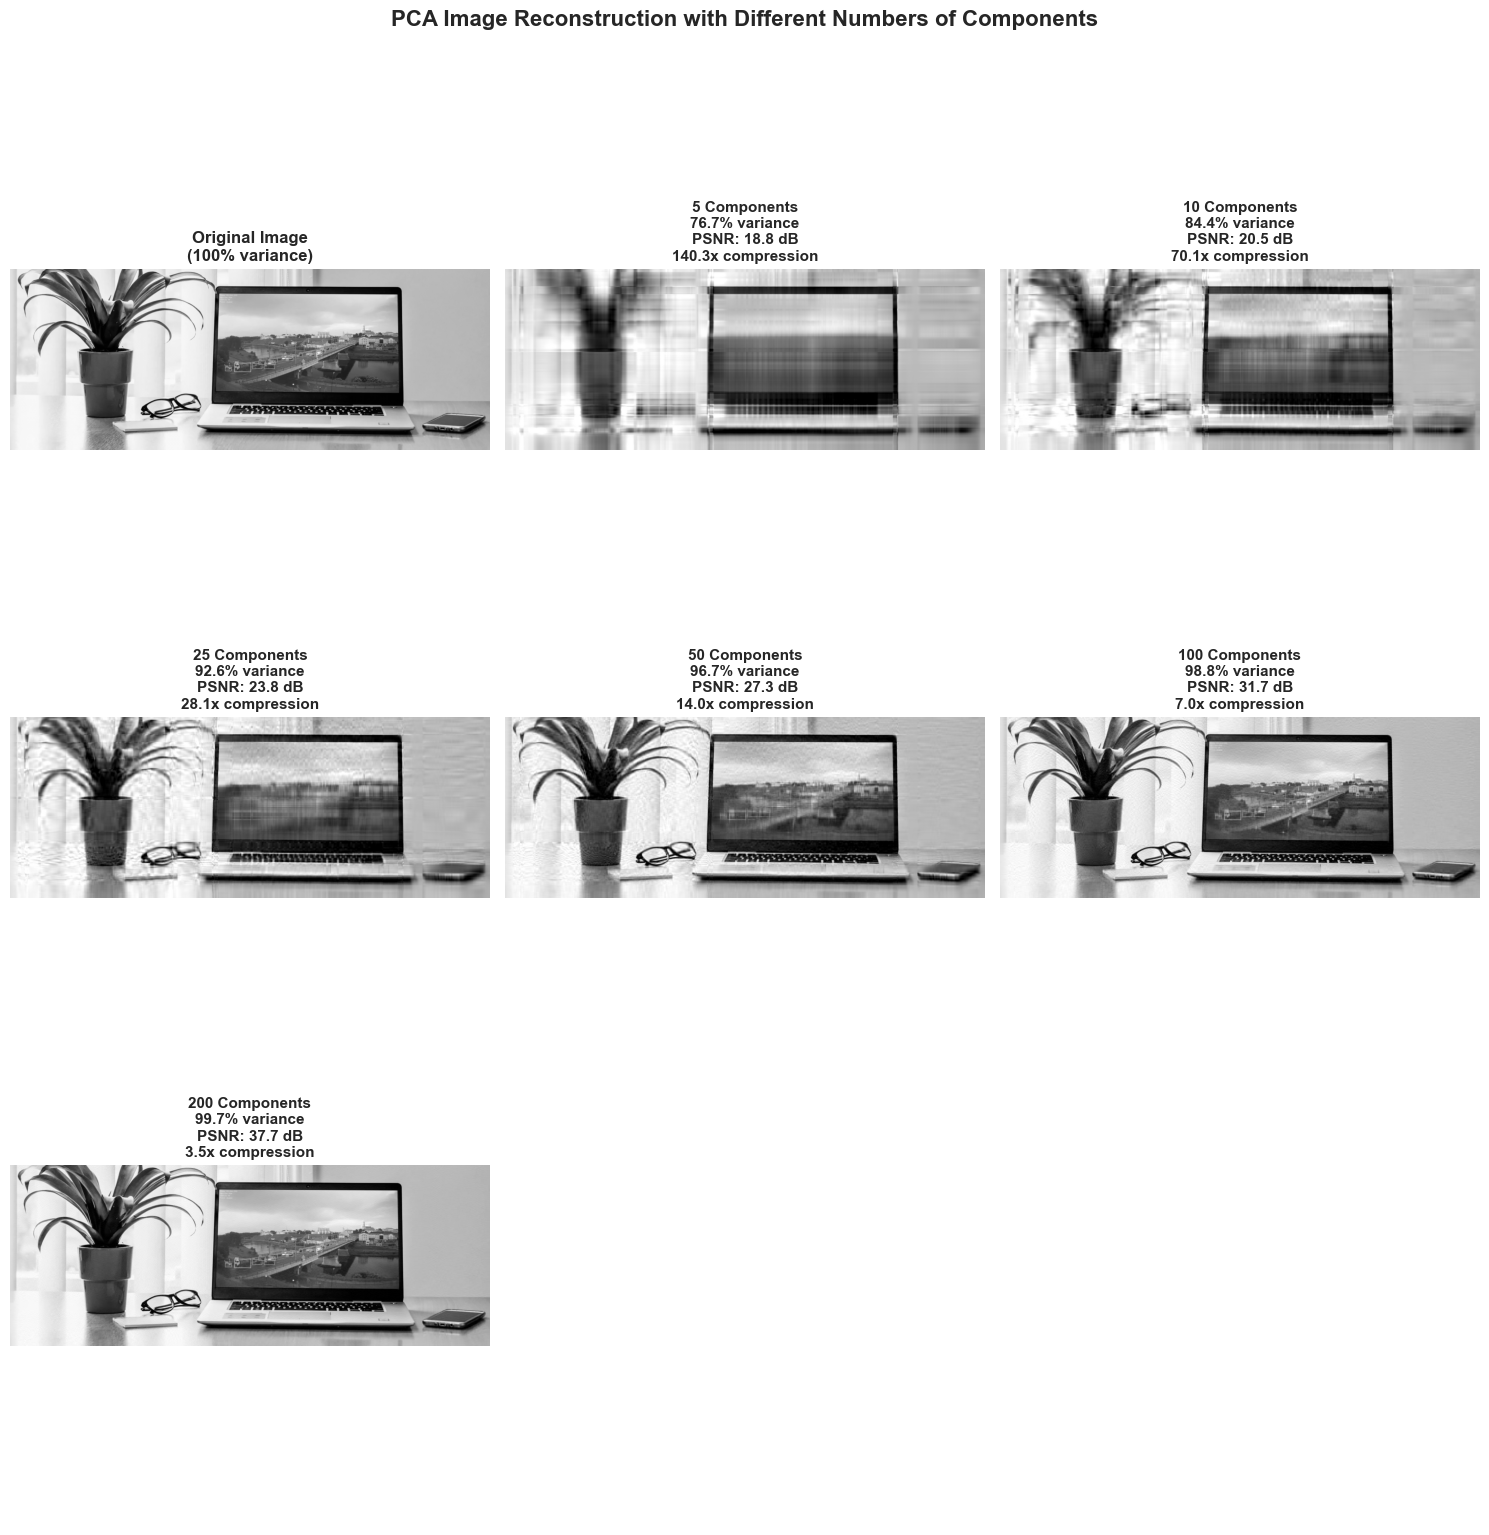

✓ Reconstruction comparison visualized


In [7]:
# Create comparison visualization
n_images = len(component_counts) + 1  # +1 for original
cols = 3
rows = (n_images + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
axes = axes.flatten() if n_images > 1 else [axes]

# Display original image
axes[0].imshow(image_normalized, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original Image\n(100% variance)', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Display reconstructed images
for idx, n_comp in enumerate(component_counts, 1):
    if idx < len(axes):
        axes[idx].imshow(reconstructions[n_comp], cmap='gray', vmin=0, vmax=1)
        
        m = metrics[n_comp]
        title = f'{n_comp} Components\n'
        title += f'{m["variance_explained"]:.1%} variance\n'
        title += f'PSNR: {m["psnr"]:.1f} dB\n'
        title += f'{m["compression_ratio"]:.1f}x compression'
        
        axes[idx].set_title(title, fontsize=11, fontweight='bold')
        axes[idx].axis('off')

# Hide unused subplots
for idx in range(n_images, len(axes)):
    axes[idx].axis('off')

plt.suptitle('PCA Image Reconstruction with Different Numbers of Components', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/pca/reconstructed/comparison_grid.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Reconstruction comparison visualized")

## 8. Quality Metrics Analysis

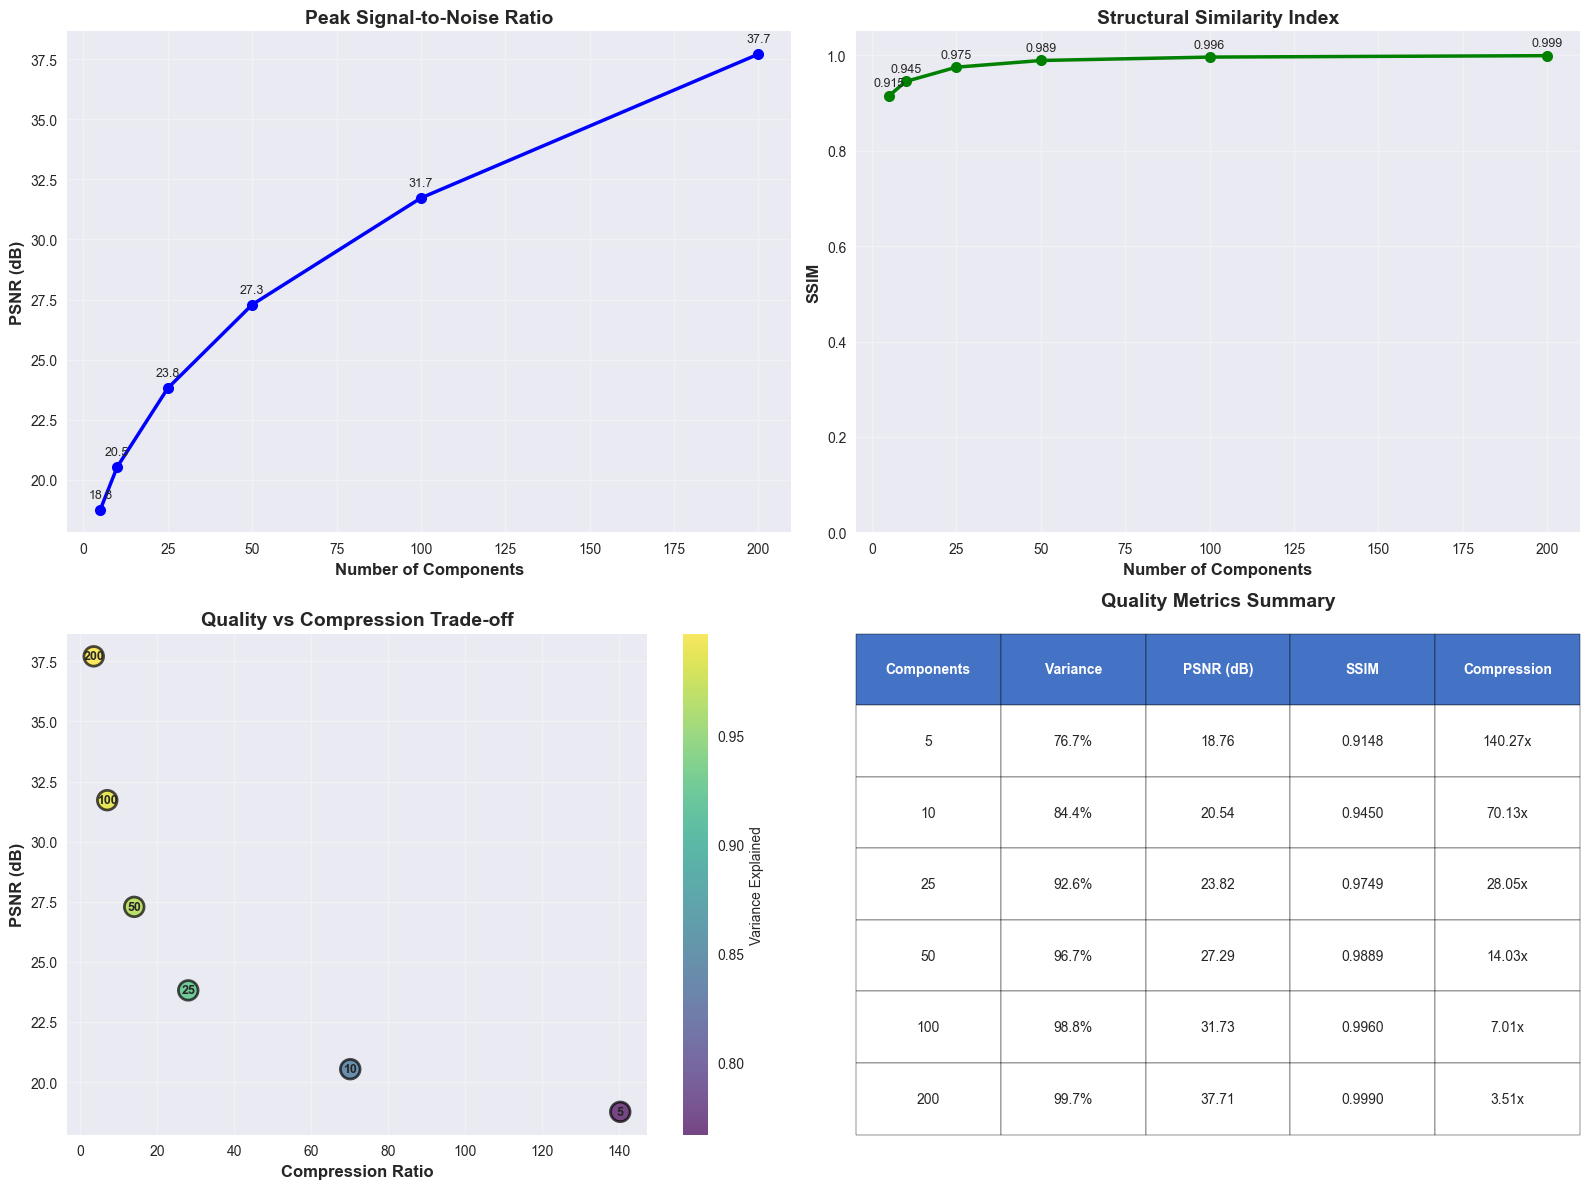

✓ Quality metrics analysis complete


In [8]:
# Create metrics visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

components = list(metrics.keys())
psnr_values = [metrics[k]['psnr'] for k in components]
ssim_values = [metrics[k]['ssim'] for k in components]
variance_values = [metrics[k]['variance_explained'] for k in components]
compression_values = [metrics[k]['compression_ratio'] for k in components]

# 1. PSNR vs Components
ax1 = axes[0, 0]
ax1.plot(components, psnr_values, 'bo-', linewidth=2.5, markersize=8)
ax1.set_xlabel('Number of Components', fontsize=12, fontweight='bold')
ax1.set_ylabel('PSNR (dB)', fontsize=12, fontweight='bold')
ax1.set_title('Peak Signal-to-Noise Ratio', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
# Add value labels
for x, y in zip(components, psnr_values):
    ax1.text(x, y + 0.5, f'{y:.1f}', ha='center', fontsize=9)

# 2. SSIM vs Components
ax2 = axes[0, 1]
ax2.plot(components, ssim_values, 'go-', linewidth=2.5, markersize=8)
ax2.set_xlabel('Number of Components', fontsize=12, fontweight='bold')
ax2.set_ylabel('SSIM', fontsize=12, fontweight='bold')
ax2.set_title('Structural Similarity Index', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.05])
# Add value labels
for x, y in zip(components, ssim_values):
    ax2.text(x, y + 0.02, f'{y:.3f}', ha='center', fontsize=9)

# 3. Quality vs Compression trade-off
ax3 = axes[1, 0]
scatter = ax3.scatter(compression_values, psnr_values, s=200, c=variance_values, 
                     cmap='viridis', edgecolors='black', linewidth=2, alpha=0.7)
ax3.set_xlabel('Compression Ratio', fontsize=12, fontweight='bold')
ax3.set_ylabel('PSNR (dB)', fontsize=12, fontweight='bold')
ax3.set_title('Quality vs Compression Trade-off', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
# Add labels
for x, y, n in zip(compression_values, psnr_values, components):
    ax3.text(x, y, f'{n}', ha='center', va='center', fontsize=9, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Variance Explained', fontsize=10)

# 4. Metrics summary table
ax4 = axes[1, 1]
ax4.axis('tight')
ax4.axis('off')

table_data = []
for n_comp in components:
    m = metrics[n_comp]
    table_data.append([
        n_comp,
        f"{m['variance_explained']:.1%}",
        f"{m['psnr']:.2f}",
        f"{m['ssim']:.4f}",
        f"{m['compression_ratio']:.2f}x"
    ])

table = ax4.table(cellText=table_data,
                 colLabels=['Components', 'Variance', 'PSNR (dB)', 'SSIM', 'Compression'],
                 cellLoc='center',
                 loc='center',
                 bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header
for i in range(5):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

ax4.set_title('Quality Metrics Summary', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../results/pca/analysis/quality_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Quality metrics analysis complete")

## 9. Visualize Principal Components

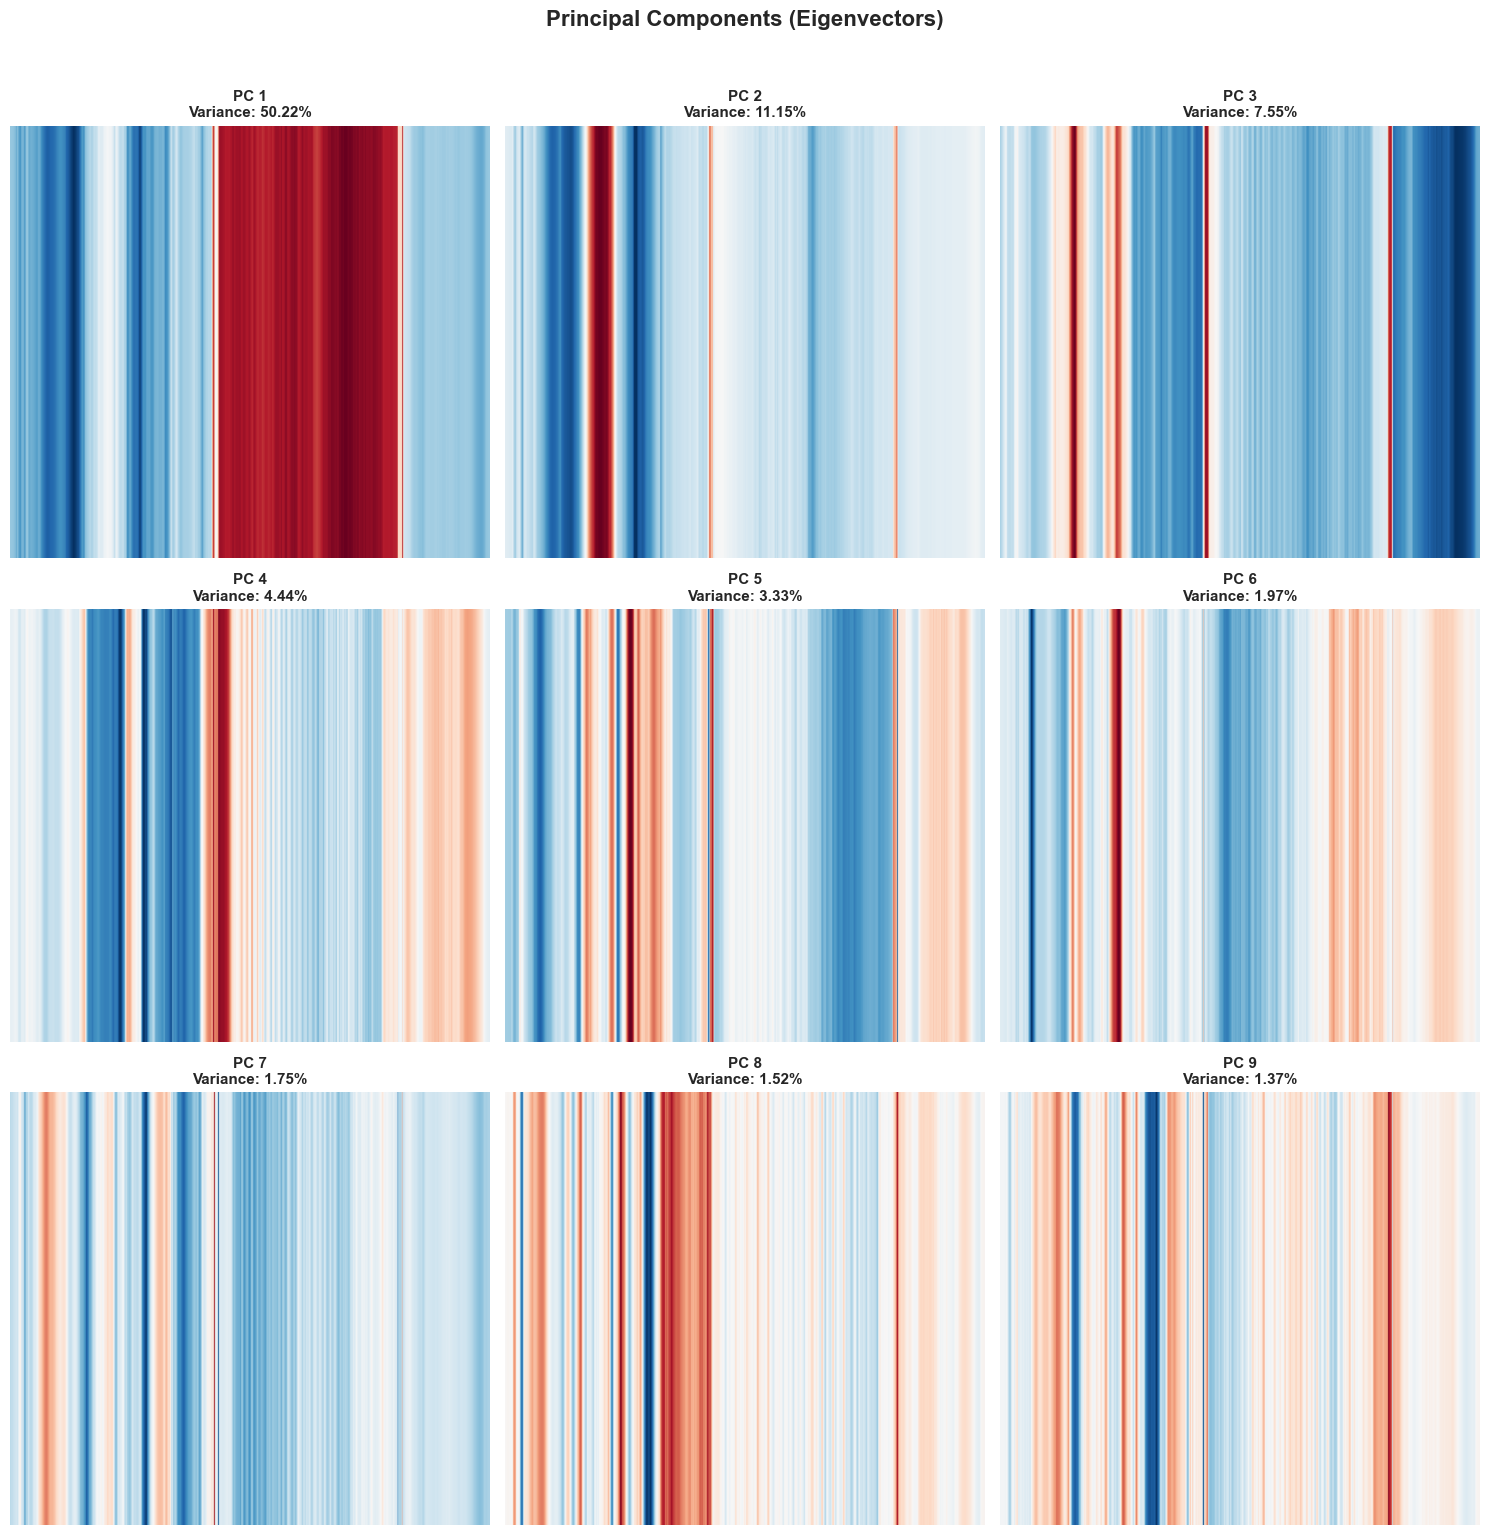

✓ Principal components visualized


In [9]:
# Visualize the first few principal components
n_components_show = min(9, len(pca_full.components_))
cols = 3
rows = (n_components_show + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
axes = axes.flatten() if n_components_show > 1 else [axes]

for i in range(n_components_show):
    # Reshape component to image dimensions
    component = pca_full.components_[i].reshape(1, -1)
    
    # Normalize for visualization
    comp_min, comp_max = component.min(), component.max()
    component_norm = (component - comp_min) / (comp_max - comp_min) if comp_max > comp_min else component
    
    axes[i].imshow(component_norm, cmap='RdBu_r', aspect='auto')
    axes[i].set_title(f'PC {i+1}\nVariance: {explained_variance_ratio[i]:.2%}', 
                     fontsize=11, fontweight='bold')
    axes[i].axis('off')

# Hide unused subplots
for i in range(n_components_show, len(axes)):
    axes[i].axis('off')

plt.suptitle('Principal Components (Eigenvectors)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/pca/analysis/principal_components.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Principal components visualized")

## 10. Save Results

In [10]:
# Save reconstructed images
for n_comp in component_counts:
    # Convert to uint8 [0, 255]
    img_uint8 = (reconstructions[n_comp] * 255).astype(np.uint8)
    
    # Save image
    filename = f'../results/pca/reconstructed/reconstructed_{n_comp}_components.png'
    cv2.imwrite(filename, img_uint8)
    
print("✓ Reconstructed images saved")

# Save metrics to CSV
metrics_df = pd.DataFrame([
    {
        'Components': n_comp,
        'Variance_Explained': f"{metrics[n_comp]['variance_explained']:.4f}",
        'MSE': f"{metrics[n_comp]['mse']:.6f}",
        'PSNR_dB': f"{metrics[n_comp]['psnr']:.2f}",
        'SSIM': f"{metrics[n_comp]['ssim']:.4f}",
        'Compression_Ratio': f"{metrics[n_comp]['compression_ratio']:.2f}"
    }
    for n_comp in component_counts
])

metrics_df.to_csv('../results/pca/pca_metrics.csv', index=False)
print("✓ Metrics CSV saved")

# Save variance analysis
variance_df = pd.DataFrame({
    'Component': range(1, len(explained_variance_ratio) + 1),
    'Variance_Ratio': explained_variance_ratio,
    'Cumulative_Variance': cumulative_variance
})
variance_df.to_csv('../results/pca/variance_analysis.csv', index=False)
print("✓ Variance analysis CSV saved")

# Save summary report
report_path = '../results/pca/pca_summary.txt'
with open(report_path, 'w') as f:
    f.write("PCA DIMENSIONALITY REDUCTION SUMMARY\n")
    f.write("=" * 70 + "\n\n")
    
    f.write("IMAGE INFORMATION:\n")
    f.write(f"  Path: {image_path}\n")
    f.write(f"  Size: {width}x{height}\n")
    f.write(f"  Total pixels: {original_shape[0] * original_shape[1]:,}\n\n")
    
    f.write("PCA ANALYSIS:\n")
    f.write(f"  Total components computed: {len(explained_variance_ratio)}\n")
    f.write(f"  First component variance: {explained_variance_ratio[0]:.2%}\n")
    f.write(f"  Top 10 components variance: {cumulative_variance[9]:.2%}\n\n")
    
    f.write("RECONSTRUCTION RESULTS:\n")
    f.write("-" * 70 + "\n")
    for n_comp in component_counts:
        m = metrics[n_comp]
        f.write(f"\n  {n_comp} Components:\n")
        f.write(f"    Variance explained: {m['variance_explained']:.2%}\n")
        f.write(f"    PSNR: {m['psnr']:.2f} dB\n")
        f.write(f"    SSIM: {m['ssim']:.4f}\n")
        f.write(f"    Compression ratio: {m['compression_ratio']:.2f}x\n")
    
    f.write("\n" + "=" * 70 + "\n")

print(f"✓ Summary report saved to: {report_path}")

print("\n" + "="*70)
print("✅ ALL RESULTS SAVED SUCCESSFULLY!")
print("="*70)
print("\nOutput files:")
print("  • Reconstructed images: ../results/pca/reconstructed/")
print("  • Metrics CSV: ../results/pca/pca_metrics.csv")
print("  • Variance analysis: ../results/pca/variance_analysis.csv")
print("  • Summary report: ../results/pca/pca_summary.txt")
print("  • Analysis plots: ../results/pca/analysis/")

✓ Reconstructed images saved
✓ Metrics CSV saved
✓ Variance analysis CSV saved
✓ Summary report saved to: ../results/pca/pca_summary.txt

✅ ALL RESULTS SAVED SUCCESSFULLY!

Output files:
  • Reconstructed images: ../results/pca/reconstructed/
  • Metrics CSV: ../results/pca/pca_metrics.csv
  • Variance analysis: ../results/pca/variance_analysis.csv
  • Summary report: ../results/pca/pca_summary.txt
  • Analysis plots: ../results/pca/analysis/


## 11. Summary and Conclusions

In [11]:
print("="*70)
print("PCA DIMENSIONALITY REDUCTION SUMMARY")
print("="*70)

print("\n🖼️ IMAGE INFORMATION:")
print("-" * 50)
print(f"  Image: {image_path}")
print(f"  Dimensions: {width}x{height} pixels")
print(f"  Total features: {original_shape[0] * original_shape[1]:,}")
print(f"  Original size: {original_shape[0] * original_shape[1]:,} values")

print("\n📊 PCA ANALYSIS:")
print("-" * 50)
print(f"  Total components: {len(explained_variance_ratio)}")
print(f"  First component: {explained_variance_ratio[0]:.2%} variance")
print(f"  Top 5 components: {cumulative_variance[4]:.2%} variance")
print(f"  Top 10 components: {cumulative_variance[9]:.2%} variance")
if len(cumulative_variance) > 49:
    print(f"  Top 50 components: {cumulative_variance[49]:.2%} variance")

print("\n🎯 RECONSTRUCTION QUALITY:")
print("-" * 50)
for n_comp in component_counts:
    m = metrics[n_comp]
    print(f"\n  {n_comp} Components:")
    print(f"    • Variance: {m['variance_explained']:.1%}")
    print(f"    • PSNR: {m['psnr']:.2f} dB")
    print(f"    • SSIM: {m['ssim']:.4f}")
    print(f"    • Compression: {m['compression_ratio']:.2f}x")

print("\n💡 KEY INSIGHTS:")
print("-" * 50)
# Find best trade-off (high PSNR with good compression)
best_tradeoff = max(component_counts, key=lambda n: metrics[n]['psnr'] / (component_counts.index(n) + 1))
print(f"  • First component captures {explained_variance_ratio[0]:.1%} of variance")
print(f"  • {component_counts[0]} components achieve {metrics[component_counts[0]]['compression_ratio']:.1f}x compression")
print(f"  • Best quality-compression trade-off: {best_tradeoff} components")
print(f"  • Diminishing returns after ~{component_counts[len(component_counts)//2]} components")

print("\n🚀 PCA ADVANTAGES:")
print("-" * 50)
print("  • Unsupervised: No labels required")
print("  • Optimal: Maximizes variance retention")
print("  • Efficient: Fast computation")
print("  • Interpretable: Ordered by importance")
print("  • Reversible: Can reconstruct original data")

print("\n🔧 USE CASES:")
print("-" * 50)
print("  • Image compression and storage")
print("  • Noise reduction and denoising")
print("  • Feature extraction for ML models")
print("  • Data visualization (reduce to 2D/3D)")
print("  • Preprocessing for other algorithms")

print("\n⚠️ LIMITATIONS:")
print("-" * 50)
print("  • Assumes linear relationships")
print("  • Sensitive to scaling")
print("  • May lose spatial structure")
print("  • Components may not be interpretable")
print("  • Better alternatives exist for complex patterns (autoencoders, etc.)")

print("\n📁 OUTPUT FILES:")
print("-" * 50)
print("  • Variance analysis plots")
print("  • Reconstructed images for different components")
print("  • Quality metrics comparison")
print("  • Principal components visualization")
print("  • CSV data and summary report")

print("\n" + "="*70)
print("✅ PCA DIMENSIONALITY REDUCTION COMPLETE!")
print("="*70)

PCA DIMENSIONALITY REDUCTION SUMMARY

🖼️ IMAGE INFORMATION:
--------------------------------------------------
  Image: ../data/Sample_Image_for_Object_Detection.png
  Dimensions: 2560x966 pixels
  Total features: 2,472,960
  Original size: 2,472,960 values

📊 PCA ANALYSIS:
--------------------------------------------------
  Total components: 966
  First component: 50.22% variance
  Top 5 components: 76.69% variance
  Top 10 components: 84.42% variance
  Top 50 components: 96.69% variance

🎯 RECONSTRUCTION QUALITY:
--------------------------------------------------

  5 Components:
    • Variance: 76.7%
    • PSNR: 18.76 dB
    • SSIM: 0.9148
    • Compression: 140.27x

  10 Components:
    • Variance: 84.4%
    • PSNR: 20.54 dB
    • SSIM: 0.9450
    • Compression: 70.13x

  25 Components:
    • Variance: 92.6%
    • PSNR: 23.82 dB
    • SSIM: 0.9749
    • Compression: 28.05x

  50 Components:
    • Variance: 96.7%
    • PSNR: 27.29 dB
    • SSIM: 0.9889
    • Compression: 14.03x

  